In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.inspection import permutation_importance
import joblib

print('Imports OK')

Imports OK


# Système Intelligent de Maintenance Prédictive Industrielle
## Bloc 1 — Data Science

**Tâche prédictive choisie :** Classification binaire — `failure_within_24h`

**Pipeline :**
1. Analyse exploratoire (EDA)
2. Nettoyage & Preprocessing
3. Entraînement de 3 modèles ML (Logistic Regression, Random Forest, Gradient Boosting)
4. Évaluation comparative & SHAP

---
## 1. Analyse Exploratoire (EDA)

In [24]:
DATA_PATH = Path('data') / 'industrial_machine_maintenance.csv'
if not DATA_PATH.exists():
    DATA_PATH = Path('industrial_machine_maintenance.csv')

dataset = pd.read_csv(DATA_PATH)
print(f'Dimensions : {dataset.shape}')
print(f'\nTypes des colonnes :\n{dataset.dtypes}')
print('\nStatistiques descriptives :')
dataset.describe()

Dimensions : (24042, 15)

Types des colonnes :
timestamp                      str
machine_id                   int64
machine_type                   str
vibration_rms              float64
temperature_motor          float64
current_phase_avg          float64
pressure_level             float64
rpm                        float64
operating_mode                 str
hours_since_maintenance    float64
ambient_temp               float64
rul_hours                  float64
failure_within_24h           int64
failure_type                   str
estimated_repair_cost        int64
dtype: object

Statistiques descriptives :


,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000


Valeurs manquantes par colonne :
vibration_rms        1000
temperature_motor     834
current_phase_avg     731
pressure_level        924
rpm                   533


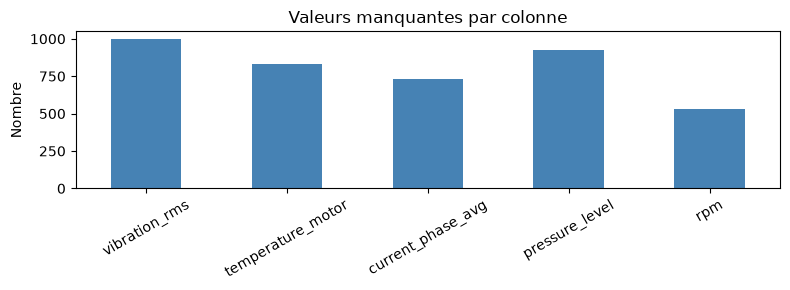

In [25]:
# --- Valeurs manquantes ---
missing = dataset.isnull().sum()
missing = missing[missing > 0]
print('Valeurs manquantes par colonne :')
print(missing.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
missing.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Valeurs manquantes par colonne')
ax.set_ylabel('Nombre')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

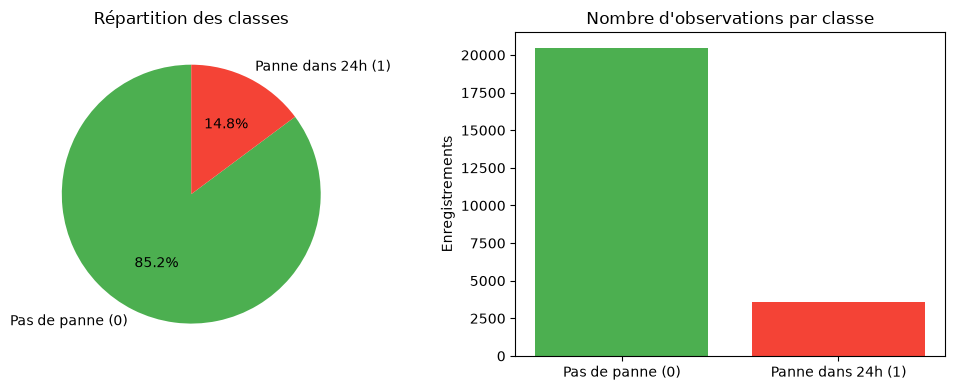


Ratio de déséquilibre : 5.8:1 (classe 0 vs classe 1)
→ Déséquilibre significatif : utiliser class_weight="balanced" et métriques F1/Recall/ROC-AUC


In [26]:
# --- Déséquilibre des classes ---
counts = dataset['failure_within_24h'].value_counts()
labels = ['Pas de panne (0)', 'Panne dans 24h (1)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Répartition des classes')
axes[1].bar(labels, counts, color=['#4CAF50', '#F44336'])
axes[1].set_title("Nombre d'observations par classe")
axes[1].set_ylabel("Enregistrements")
plt.tight_layout()
plt.show()
print(f'\nRatio de déséquilibre : {counts[0]/counts[1]:.1f}:1 (classe 0 vs classe 1)')
print('→ Déséquilibre significatif : utiliser class_weight="balanced" et métriques F1/Recall/ROC-AUC')

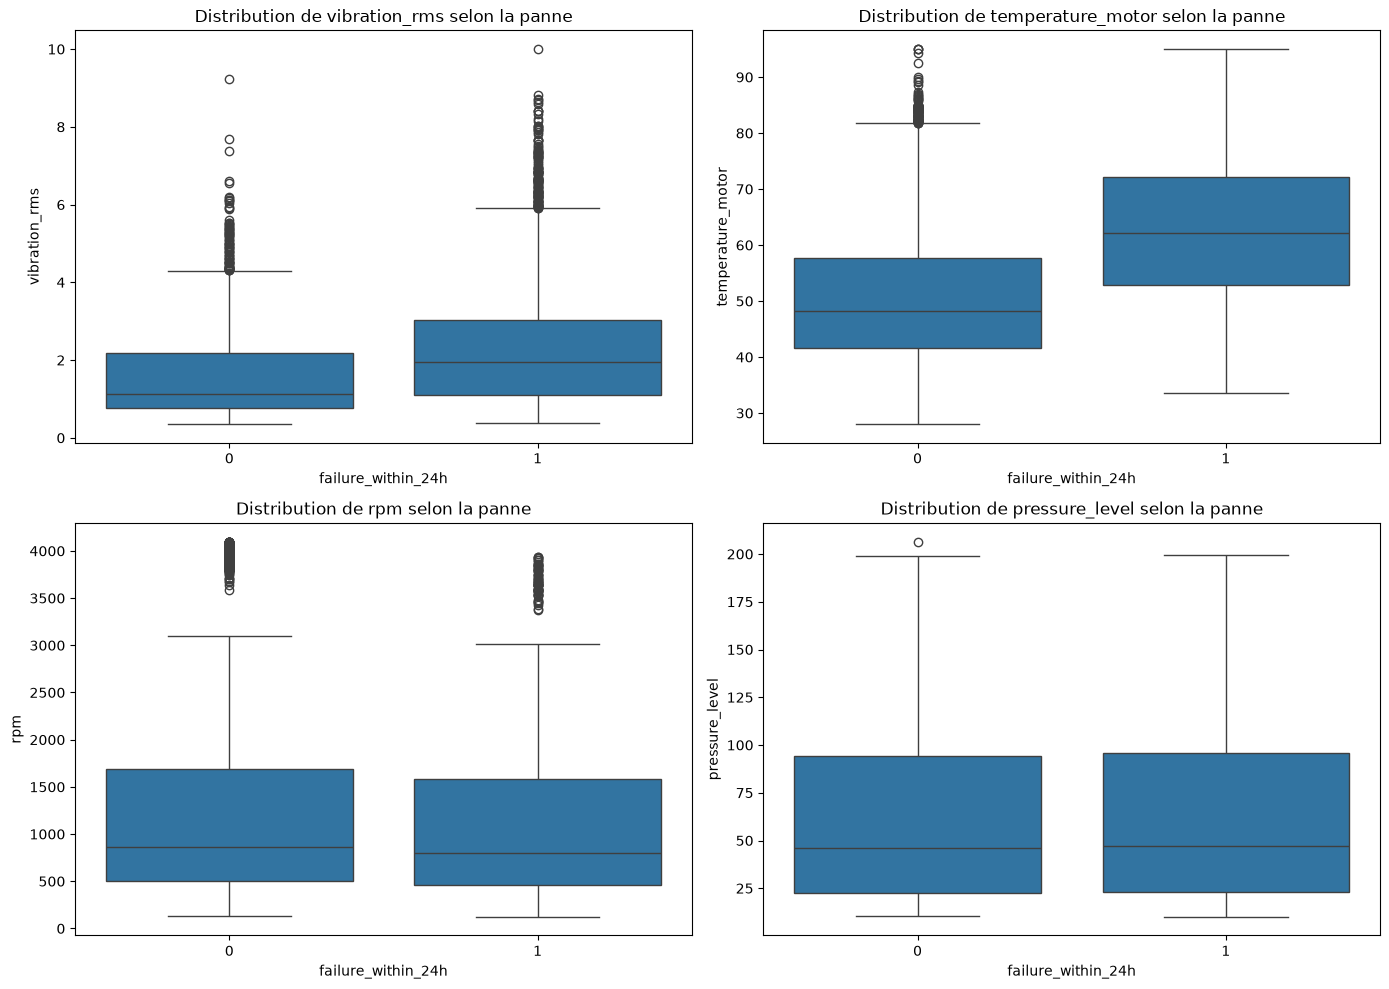

In [27]:
# --- Boxplots : distribution des capteurs selon la panne (travail du binôme) ---
capteurs = ['vibration_rms', 'temperature_motor', 'rpm', 'pressure_level']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(capteurs):
    row = i // 2
    col_idx = i % 2
    sns.boxplot(x='failure_within_24h', y=col, data=dataset, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribution de {col} selon la panne')

plt.tight_layout()
plt.show()

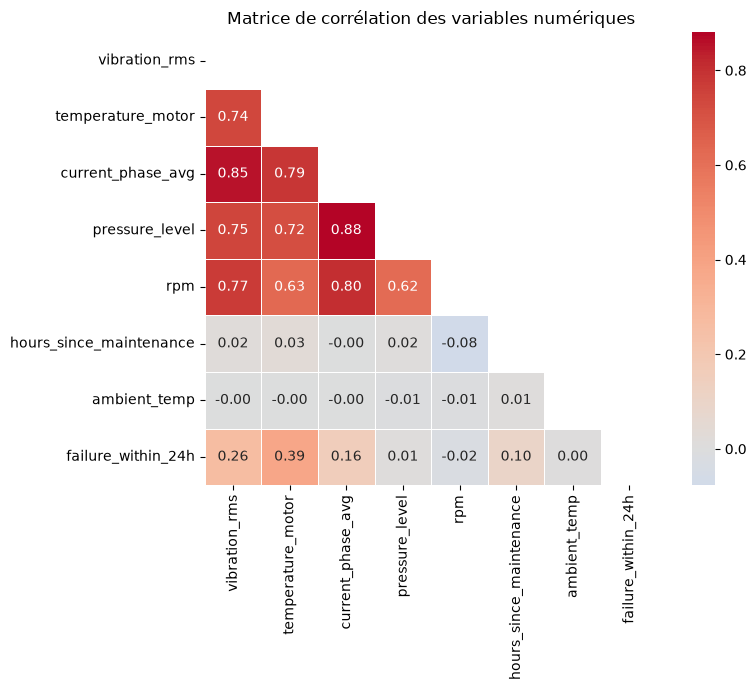

In [28]:
# --- Matrice de corrélation ---
numeric_cols = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']

fig, ax = plt.subplots(figsize=(9, 7))
corr = dataset[numeric_cols + ['failure_within_24h']].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()

## 2. Nettoyage & Preprocessing

### Sélection des features

Colonnes **exclues** car elles constituent une fuite de données (*data leakage*) :
- `rul_hours` : durée de vie restante → directement liée à `failure_within_24h`
- `estimated_repair_cost` : coût de réparation → 0 quand pas de panne (info post-événement)
- `failure_type` : type de panne → info post-événement
- `machine_id`, `timestamp` : identifiants sans valeur prédictive
- `machine_type`, `operating_mode` : variables catégorielles (non encodées ici pour rester proche de l'approche initiale)

In [29]:
LEAKAGE_COLS = ['rul_hours', 'estimated_repair_cost', 'failure_type', 'machine_id', 'timestamp']
TARGET = 'failure_within_24h'

X = dataset.drop(columns=[TARGET] + LEAKAGE_COLS, errors='ignore')
y = dataset[TARGET]

non_numeric_cols = X.select_dtypes(include=['object', 'datetime64[ns]']).columns.tolist()
X = X.drop(columns=non_numeric_cols, errors='ignore')

FEATURE_NAMES = X.columns.tolist()
print(f'Features retenues ({len(FEATURE_NAMES)}) : {FEATURE_NAMES}')
print(f'Dimensions de X : {X.shape}')
print(f'Dimensions de y : {y.shape}')

Features retenues (7) : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']
Dimensions de X : (24042, 7)
Dimensions de y : (24042,)


In [30]:
# Division stratifiée (préserve le ratio de classes dans train et test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'Taux de panne train : {y_train.mean():.1%}  |  test : {y_test.mean():.1%}')

X_train : (16829, 7)  |  X_test : (7213, 7)
Taux de panne train : 14.8%  |  test : 14.8%


In [31]:
# Imputation par la médiane (ajustée sur train uniquement → évite le data leakage)
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURE_NAMES)
X_test_imputed  = pd.DataFrame(imputer.transform(X_test),      columns=FEATURE_NAMES)

# Standardisation (ajustée sur train uniquement)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=FEATURE_NAMES)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imputed),      columns=FEATURE_NAMES)

print(f'Valeurs manquantes X_train_imputed : {X_train_imputed.isnull().sum().sum()}')
print(f'Valeurs manquantes X_test_imputed  : {X_test_imputed.isnull().sum().sum()}')
print('Preprocessing OK')

Valeurs manquantes X_train_imputed : 0
Valeurs manquantes X_test_imputed  : 0
Preprocessing OK


In [32]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_imputed, y_train)

print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")
print(f"Après SMOTE : {y_train_sm.value_counts().to_dict()}")

Avant SMOTE : {0: 14337, 1: 2492}
Après SMOTE : {0: 14337, 1: 14337}


In [33]:
all_metrics_smote = []

lr_sm = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_sm_metrics, _, _ = evaluate_model(
    'Logistic Regression + SMOTE', lr_sm,
    X_train_sm, X_test_imputed, y_train_sm, y_test
)
all_metrics_smote.append(lr_sm_metrics)

rf_sm = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_sm_metrics, _, _ = evaluate_model(
    'Random Forest + SMOTE', rf_sm,
    X_train_sm, X_test_imputed, y_train_sm, y_test
)
all_metrics_smote.append(rf_sm_metrics)

gb_sm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb_sm_metrics, _, _ = evaluate_model(
    'Gradient Boosting + SMOTE', gb_sm,
    X_train_sm, X_test_imputed, y_train_sm, y_test
)
all_metrics_smote.append(gb_sm_metrics)

NameError: name 'evaluate_model' is not defined

In [ ]:
df_sans = pd.DataFrame(all_metrics).set_index('name')
df_avec = pd.DataFrame(all_metrics_smote).set_index('name')

print("=== Sans SMOTE ===")
display(df_sans)

print("\n=== Avec SMOTE ===")
display(df_avec)

=== Sans SMOTE ===


,accuracy,precision,recall,f1,roc_auc
name,,,,,
Logistic Regression (baseline),0.8885,0.5840,0.8596,0.6955,0.9399
Random Forest,0.9597,0.8246,0.9242,0.8715,0.9916
Gradient Boosting,0.9566,0.8764,0.8230,0.8489,0.9856



=== Avec SMOTE ===


,accuracy,precision,recall,f1,roc_auc
name,,,,,
Logistic Regression + SMOTE,0.8913,0.5922,0.8539,0.6994,0.9398
Random Forest + SMOTE,0.9583,0.8100,0.9382,0.8694,0.9907
Gradient Boosting + SMOTE,0.9387,0.7271,0.9382,0.8193,0.9851


In [ ]:
# Fonction d'évaluation réutilisable pour les 3 modèles
def evaluate_model(name, clf, X_tr, X_te, y_tr, y_te):
    clf.fit(X_tr, y_tr)
    y_pred  = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)[:, 1]
    metrics = {
        'name':      name,
        'accuracy':  round(accuracy_score(y_te, y_pred),  4),
        'precision': round(precision_score(y_te, y_pred), 4),
        'recall':    round(recall_score(y_te, y_pred),    4),
        'f1':        round(f1_score(y_te, y_pred),        4),
        'roc_auc':   round(roc_auc_score(y_te, y_proba),  4),
    }
    print(f'\n=== {name} ===')
    for k, v in metrics.items():
        if k != 'name':
            print(f'  {k:<12}: {v:.4f}')
    print('\nMatrice de confusion :')
    cm = confusion_matrix(y_te, y_pred)
    display(pd.DataFrame(cm, index=['Réel 0', 'Réel 1'], columns=['Prédit 0', 'Prédit 1']))
    print('\nRapport de classification :')
    print(classification_report(y_te, y_pred))
    return metrics, y_pred, y_proba

all_metrics = []

## 3. Entraînement et Évaluation des Modèles

**Stratégie :**
- 3 modèles comparés : Logistic Regression (baseline), Random Forest, Gradient Boosting
- Métriques adaptées au déséquilibre : Recall, F1, ROC-AUC (pas uniquement l'Accuracy)
- `class_weight='balanced'` pour compenser le déséquilibre 85/15

### Modèle 1 — Logistic Regression (Baseline)

In [ ]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_metrics, lr_pred, lr_proba = evaluate_model(
    'Logistic Regression (baseline)', lr,
    X_train_scaled, X_test_scaled, y_train, y_test
)
all_metrics.append(lr_metrics)


=== Logistic Regression (baseline) ===
  accuracy    : 0.8885
  precision   : 0.5840
  recall      : 0.8596
  f1          : 0.6955
  roc_auc     : 0.9399

Matrice de confusion :


,Prédit 0,Prédit 1
Réel 0,5491,654
Réel 1,150,918



Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      6145
           1       0.58      0.86      0.70      1068

    accuracy                           0.89      7213
   macro avg       0.78      0.88      0.81      7213
weighted avg       0.92      0.89      0.90      7213



### Modèle 2 — Random Forest

Entraînement d'un `RandomForestClassifier` sur les données imputées.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_metrics, rf_pred, rf_proba = evaluate_model(
    'Random Forest', rf,
    X_train_imputed, X_test_imputed, y_train, y_test
)
all_metrics.append(rf_metrics)


=== Random Forest ===
  accuracy    : 0.9597
  precision   : 0.8246
  recall      : 0.9242
  f1          : 0.8715
  roc_auc     : 0.9916

Matrice de confusion :


,Prédit 0,Prédit 1
Réel 0,5935,210
Réel 1,81,987



Rapport de classification :
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      6145
           1       0.82      0.92      0.87      1068

    accuracy                           0.96      7213
   macro avg       0.91      0.94      0.92      7213
weighted avg       0.96      0.96      0.96      7213



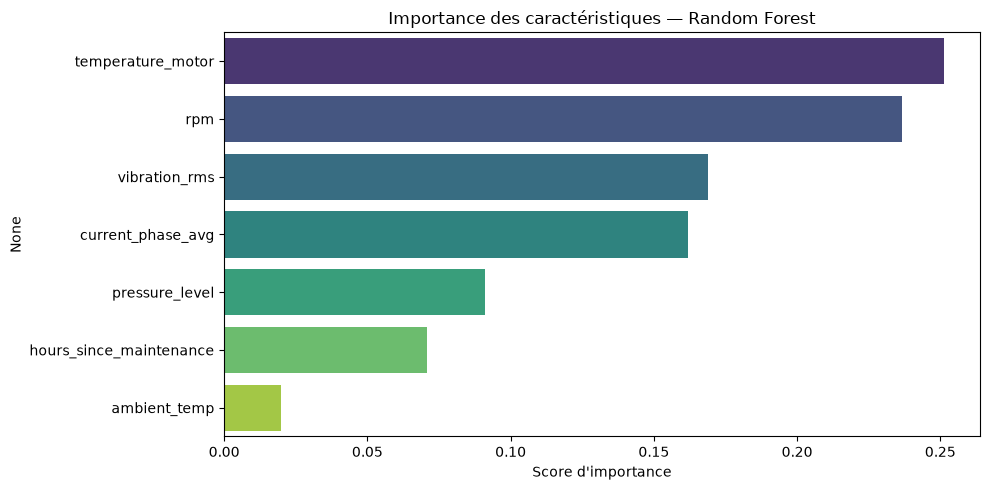

In [ ]:
# Importance des caractéristiques — Random Forest (native)
feature_importances = pd.Series(
    rf.feature_importances_, index=FEATURE_NAMES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis', ax=ax)
ax.set_title("Importance des caractéristiques — Random Forest")
ax.set_xlabel("Score d'importance")
plt.tight_layout()
plt.show()

### Modèle 3 — Gradient Boosting

Le Gradient Boosting construit des arbres de manière séquentielle en corrigeant les erreurs du modèle précédent. Il capture des interactions non-linéaires complexes.

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb_metrics, gb_pred, gb_proba = evaluate_model(
    'Gradient Boosting', gb,
    X_train_imputed, X_test_imputed, y_train, y_test
)
all_metrics.append(gb_metrics)


=== Gradient Boosting ===
  accuracy    : 0.9566
  precision   : 0.8764
  recall      : 0.8230
  f1          : 0.8489
  roc_auc     : 0.9856

Matrice de confusion :


,Prédit 0,Prédit 1
Réel 0,6021,124
Réel 1,189,879



Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      6145
           1       0.88      0.82      0.85      1068

    accuracy                           0.96      7213
   macro avg       0.92      0.90      0.91      7213
weighted avg       0.96      0.96      0.96      7213



## 4. Comparaison des Modèles et Sélection du Meilleur

**Métriques clés en contexte industriel :**
- **Recall** : priorité absolue → minimiser les faux négatifs (pannes non détectées)
- **F1-score** : compromis Precision/Recall
- **ROC-AUC** : capacité globale de discrimination

=== Tableau comparatif des 3 modèles ===


,accuracy,precision,recall,f1,roc_auc
name,,,,,
Logistic Regression (baseline),0.8885,0.5840,0.8596,0.6955,0.9399
Random Forest,0.9597,0.8246,0.9242,0.8715,0.9916
Gradient Boosting,0.9566,0.8764,0.8230,0.8489,0.9856


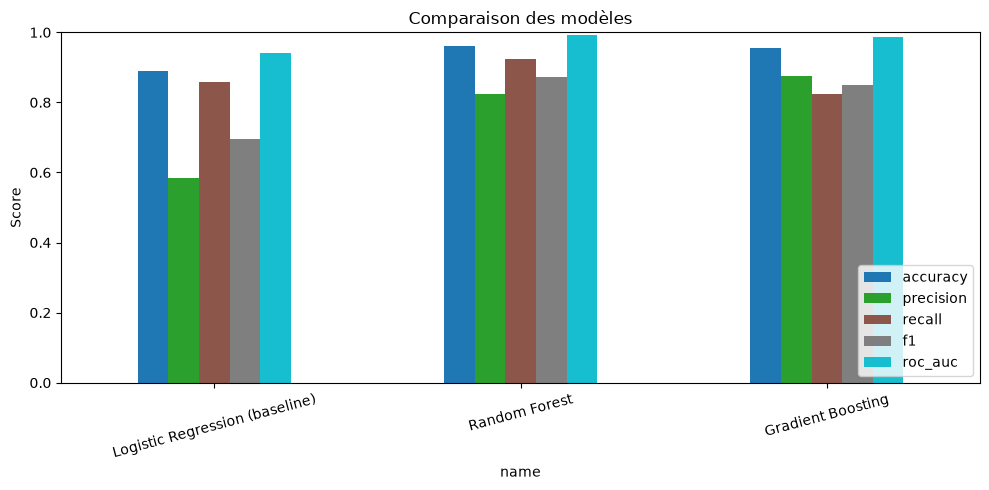

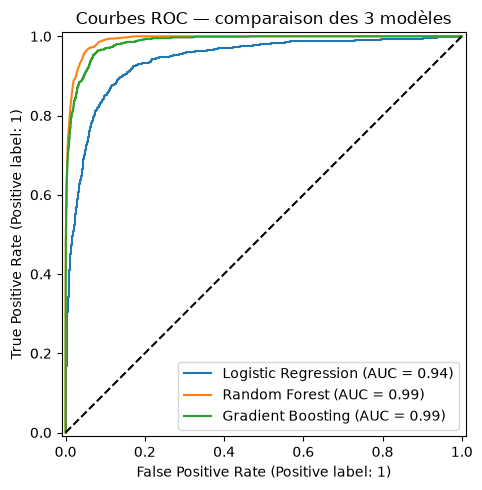


Modèle retenu (meilleur F1-score) : Random Forest
Justification : dans ce contexte industriel, le F1-score reflète le
compromis Precision/Recall. Réduire les faux négatifs (pannes non détectées) est prioritaire.


In [ ]:
comparison_df = pd.DataFrame(all_metrics).set_index('name')
print('=== Tableau comparatif des 3 modèles ===')
display(comparison_df)

fig, ax = plt.subplots(figsize=(10, 5))
comparison_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(
    kind='bar', ax=ax, colormap='tab10'
)
ax.set_title('Comparaison des modèles')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, lr_proba, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, gb_proba, name='Gradient Boosting', ax=ax)
ax.plot([0, 1], [0, 1], 'k--')
ax.set_title('Courbes ROC — comparaison des 3 modèles')
plt.tight_layout()
plt.show()

best_model_name = comparison_df['f1'].idxmax()
print(f'\nModèle retenu (meilleur F1-score) : {best_model_name}')
print('Justification : dans ce contexte industriel, le F1-score reflète le')
print('compromis Precision/Recall. Réduire les faux négatifs (pannes non détectées) est prioritaire.')

## 5. Interprétabilité — SHAP

SHAP explique chaque prédiction individuelle en calculant la contribution de chaque variable. Appliqué ici sur le **Gradient Boosting** (modèle final retenu).

=== SHAP — Importance globale (beeswarm) ===


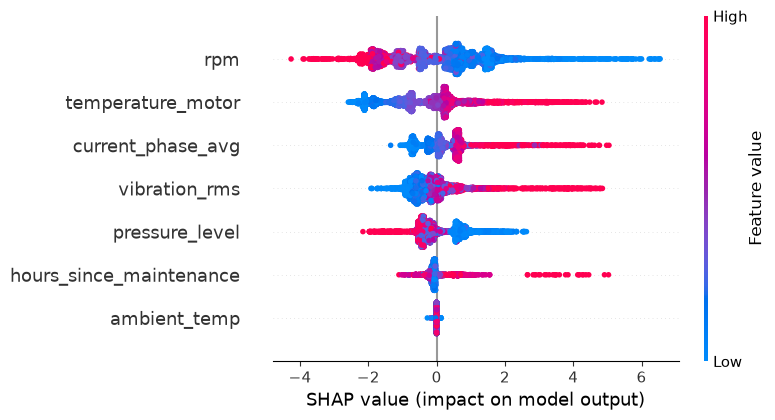


=== SHAP — Importance globale (bar chart) ===


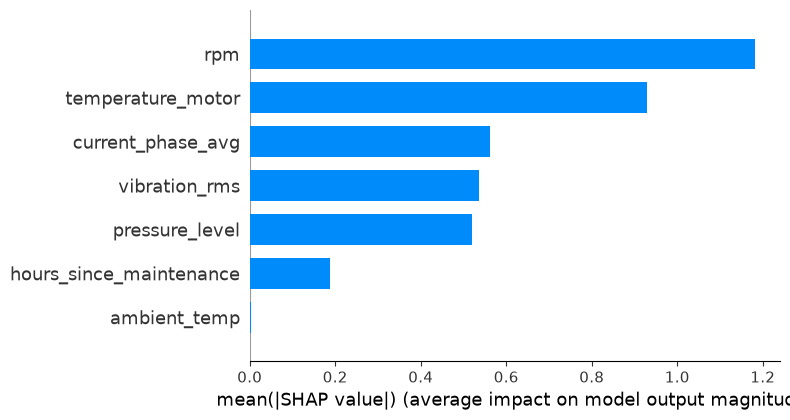


=== Explication locale — observation 16 (panne prédite) ===


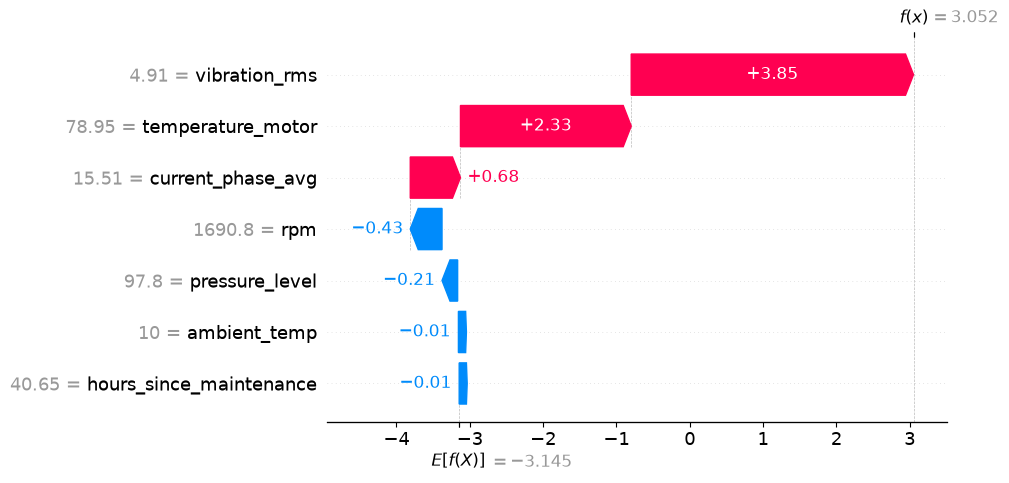

In [ ]:
try:
    import shap
    shap_ok = True
except ImportError:
    shap_ok = False
    print('SHAP non installé — exécuter : pip install shap')

if shap_ok:
    explainer = shap.TreeExplainer(gb)
    shap_values = explainer.shap_values(X_test_imputed)

    # GradientBoostingClassifier (binaire) retourne un tableau 2D (n_samples, n_features).
    # RandomForestClassifier retourne une liste [class0, class1].
    # On normalise pour toujours avoir un tableau 2D.
    if isinstance(shap_values, list):
        sv = shap_values[1]          # classe positive pour RF/multi-output
        base_val = explainer.expected_value[1]
    else:
        sv = shap_values             # déjà 2D pour GBC binaire
        base_val = explainer.expected_value

    print('=== SHAP — Importance globale (beeswarm) ===')
    shap.summary_plot(sv, X_test_imputed, feature_names=FEATURE_NAMES, show=True)

    print('\n=== SHAP — Importance globale (bar chart) ===')
    shap.summary_plot(sv, X_test_imputed, feature_names=FEATURE_NAMES,
                      plot_type='bar', show=True)

    panne_idx = int((y_test.reset_index(drop=True) == 1).idxmax())
    print(f'\n=== Explication locale — observation {panne_idx} (panne prédite) ===')
    shap.waterfall_plot(shap.Explanation(
        values=sv[panne_idx],
        base_values=float(explainer.expected_value) if np.ndim(explainer.expected_value) == 0 else float(explainer.expected_value[0]),
        data=X_test_imputed.iloc[panne_idx],
        feature_names=FEATURE_NAMES
    ))

## 6. Export des Artefacts pour le Bloc 2 (API + Dashboard)

Cette cellule sauvegarde le modèle final et ses métadonnées dans `model/` selon le format défini dans `CONTRACT.md`.

model.pkl sauvegardé → ..\model\model.pkl
metrics.json sauvegardé
feature_importance.json sauvegardé

=== Importance des variables (Permutation Importance) ===


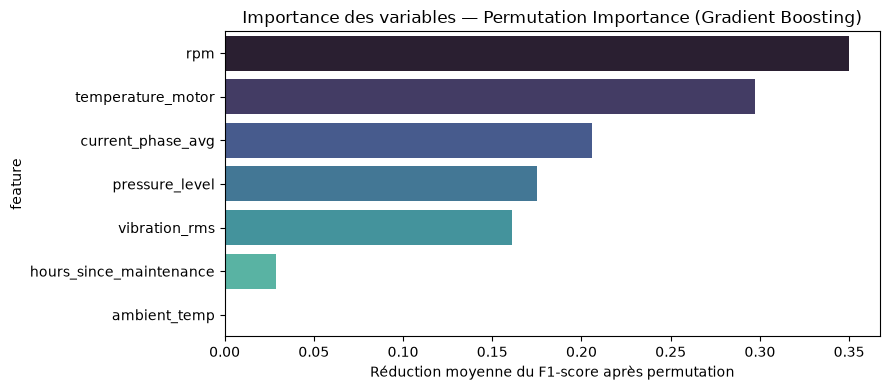


Tous les artefacts exportés. Bloc 2 prêt.


In [ ]:
MODEL_DIR = Path('..') / 'model'
MODEL_DIR.mkdir(exist_ok=True)

# Pipeline complet : imputer + scaler + Gradient Boosting
# Inclure le preprocessing dans le Pipeline permet à l'API de
# recevoir les données brutes sans reproduire le preprocessing côté serveur.
final_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('model',  GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42
    )),
])
final_pipeline.fit(X_train, y_train)
joblib.dump(final_pipeline, MODEL_DIR / 'model.pkl')
print(f'model.pkl sauvegardé → {MODEL_DIR / "model.pkl"}')

# metrics.json
metrics_payload = {'models': all_metrics, 'selected_model': best_model_name}
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)
print('metrics.json sauvegardé')

# feature_importance.json (Permutation Importance sur le pipeline final)
perm = permutation_importance(
    final_pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='f1'
)
fi_sorted = sorted(
    [{'feature': feat, 'importance': round(float(imp), 4)}
     for feat, imp in zip(FEATURE_NAMES, perm.importances_mean)],
    key=lambda d: d['importance'], reverse=True
)
fi_payload = {'method': 'permutation_importance', 'importances': fi_sorted}
with open(MODEL_DIR / 'feature_importance.json', 'w') as f:
    json.dump(fi_payload, f, indent=2)
print('feature_importance.json sauvegardé')

print('\n=== Importance des variables (Permutation Importance) ===')
fi_df = pd.DataFrame(fi_sorted).set_index('feature')
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=fi_df['importance'], y=fi_df.index, palette='mako', ax=ax)
ax.set_title('Importance des variables — Permutation Importance (Gradient Boosting)')
ax.set_xlabel('Réduction moyenne du F1-score après permutation')
plt.tight_layout()
plt.show()

print('\nTous les artefacts exportés. Bloc 2 prêt.')

In [ ]:
# Permutation Importance sur Random Forest
perm_rf = permutation_importance(
    rf_sm, X_test_imputed, y_test, 
    n_repeats=10, random_state=42, scoring='f1'
)
fi_rf = sorted(
    [{'feature': f, 'importance': round(float(i), 4)} 
     for f, i in zip(FEATURE_NAMES, perm_rf.importances_mean)],
    key=lambda d: d['importance'], reverse=True
)
fi_rf_df = pd.DataFrame(fi_rf).set_index('feature')
print(fi_rf_df)